In [1]:
import os
import uuid
import imageio
import numpy as np
from IPython.display import Image as ImageDisplay
import sys
PATH = os.getcwd()
module_dir = os.path.abspath(f"{PATH}/../sam-3d-objects/notebook/")
sys.path.append(module_dir)
from inference import Inference, ready_gaussian_for_video_rendering, load_image, load_masks, display_image, make_scene, render_video, interactive_visualizer
import torch
import pandas as pd
import matplotlib.pyplot as plt



/home/haihong/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp 1.11.1 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX 2000 Ada Generation" (16 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/haihong/.cache/warp/1.11.1


2026-03-08 10:55:12.782 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA RTX 2000 Ada Generation


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-08 10:55:14.054 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2026-03-08 10:55:16.206 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-03-08 10:55:17.163 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-08 10:55:17.163 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


# Data loading


/home/haihong/sam-3d-objects/notebook/inference.py:404: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


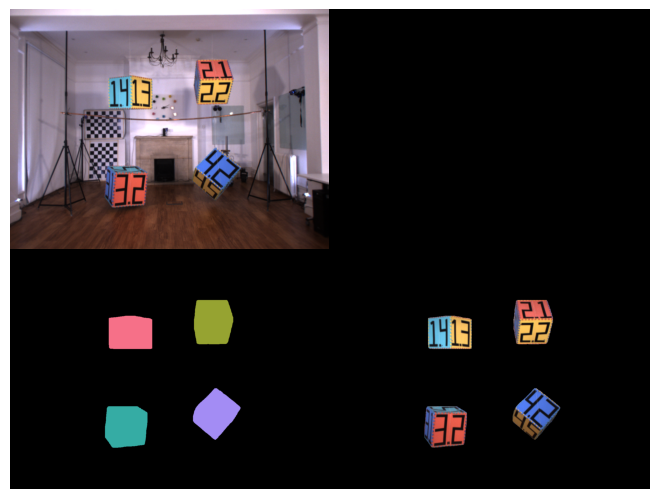

In [2]:
IMAGE_PATH = f"{PATH}/../tracking_dataset/omd_mask/000001/image.png"
IMAGE_NAME = os.path.basename(os.path.dirname(IMAGE_PATH))

image = load_image(IMAGE_PATH)
masks = load_masks(os.path.dirname(IMAGE_PATH), indices_list=[0, 2, 1, 4], extension=".png")
display_image(image, masks)

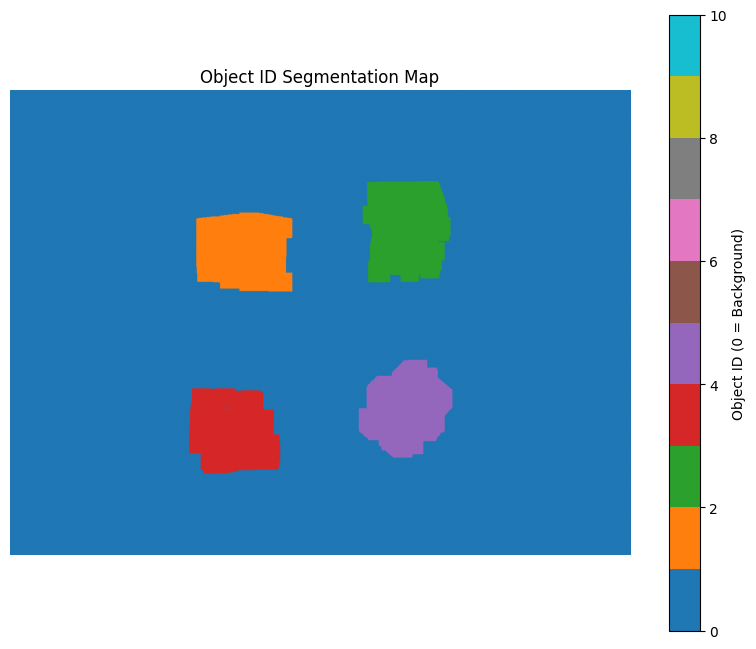

(960, 1280)


In [3]:
segment_path = f"{PATH}/../tracking_dataset/omd/semantic/000001.txt"
data = np.loadtxt(segment_path)

visual_data = data.copy()
visual_data[visual_data == -1] = 0

plt.figure(figsize=(10, 8))

plt.imshow(visual_data, cmap='tab10', vmin=0, vmax=10)

plt.colorbar(label='Object ID (0 = Background)')
plt.title('Object ID Segmentation Map')
plt.axis('off') # Hide pixel coordinates
plt.show()
print(visual_data.shape)

In [4]:
# Verify it's all there
outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache.pt")
print(outputs[0].keys())
print(outputs[1].keys())
print(outputs[2].keys())
print(outputs[3].keys())
# Access your intrinsics directly
print(outputs[0]['coords'].shape)
print(outputs[0]['pointmap'].shape)

/tmp/ipykernel_30171/1263923518.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache.pt")


dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
torch.Size([10086, 4])
torch.Size([480, 640, 3])


# Extraction and visualization of SAM3D output pointmap

In [5]:
import open3d as o3d
import torch.nn.functional as F
import matplotlib.pyplot as plt

def parse_sam3d_output(output_dict, binary_mask):
    """
    Visualizes the pointmap and pointmap_colors from SAM3D meta output.
    """
    # 1. Extract data
    # Shape of pointmap is usually (H, W, 3)
    points = output_dict.get('pointmap')
    colors = output_dict.get('pointmap_colors')
    coords = output_dict['coords']

    if points is None:
        print("Error: 'pointmap' not found in dictionary.")
        return

    if isinstance(binary_mask, np.ndarray):
        binary_mask = torch.from_numpy(binary_mask)

    mask_rescaled = F.interpolate(
        binary_mask.unsqueeze(0).unsqueeze(0).float(), 
        size=(points.shape[0], points.shape[1]), 
        mode='nearest'
    ).squeeze()
    
    y_indices, x_indices = torch.where(mask_rescaled > 0)
    y_indices = y_indices.to(points.device)
    x_indices = x_indices.to(points.device)
    filtered_points = points[y_indices, x_indices]
    filtered_colors = colors[y_indices, x_indices]
    filtered_points[:, 0] = -filtered_points[:, 0]
    filtered_points[:, 1] = -filtered_points[:, 1]

    # create dataframe with pixel-coordinate corrospondance
    pts_np = filtered_points.detach().cpu().numpy()
    u_np = x_indices.detach().cpu().numpy()
    v_np = y_indices.detach().cpu().numpy()
    
    data = {
        'x_mesh': pts_np[:, 0],
        'y_mesh': pts_np[:, 1],
        'z_mesh': pts_np[:, 2],
        'u': u_np,
        'v': v_np
    }

    df_mesh = pd.DataFrame(data)

    # scale the coordinate properly by scale factor = 2
    df_mesh['u'] = df_mesh['u'] * 2
    df_mesh['v'] = df_mesh['v'] * 2
    
    # 2. Reshape/Flatten the grids
    # We turn the (H, W, 3) image-like grid into a long list of (N, 3) points
    flat_points = filtered_points.reshape(-1, 3)
    
    # 3. Handle Colors
    if colors is not None:
        flat_colors = filtered_colors.reshape(-1, 3)
        # Ensure colors are in float range [0, 1] for Open3D
        if flat_colors.max() > 1.0:
            flat_colors = flat_colors / 255.0
    else:
        # Default to gray if no colors provided
        flat_colors = np.ones_like(flat_points) * 0.5

    # 4. Filter out invalid points (zeros or NaNs)
    # Monocular depth often produces 0s for pixels it couldn't estimate
    valid_idx = ~(flat_points == 0).all(dim=1)
    final_points = flat_points[valid_idx]
    final_colors = flat_colors[valid_idx]

    # # 5. Create Open3D PointCloud
    # pcd = o3d.geometry.PointCloud()
    # pcd.points = o3d.utility.Vector3dVector(final_points)
    # pcd.colors = o3d.utility.Vector3dVector(final_colors)

    # # 6. Visualize
    # print("Opening 3D visualization... Use mouse to rotate, scroll to zoom.")
    # # Add a coordinate frame to see the origin (Camera center)
    # coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])
    # o3d.visualization.draw_geometries([pcd, coord_frame], 
    #                                   window_name="SAM3D Pointmap Visualization")
    return final_points, final_colors, df_mesh

/tmp/ipykernel_30171/4198346973.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(output))
/tmp/ipykernel_30171/4198346973.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  img = ax.scatter(xs, ys, zs, label=f'Object ID: {i+1}', c=c_data, s=5, alpha=0.8)
/tmp/ipykernel_30171/4198346973.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *

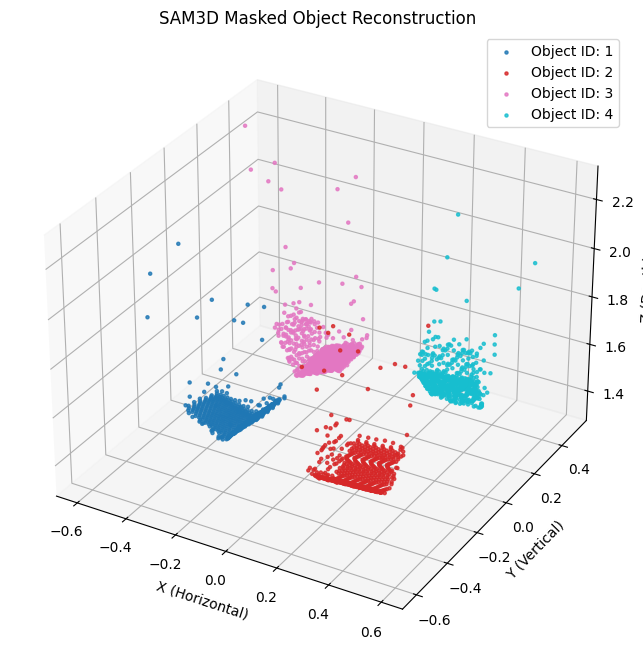

/tmp/ipykernel_30171/4198346973.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(output))


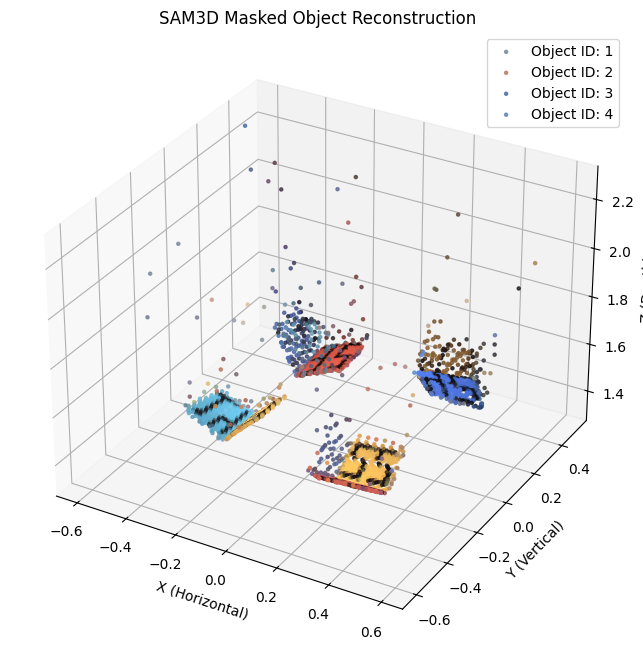

In [6]:
def matplotlib_visualize(output, masks, original_color=True, decimate_ratio=0.1):
    # 1. Create the Matplotlib Figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    # Set labels
    ax.set_xlabel('X (Horizontal)')
    ax.set_ylabel('Y (Vertical)')
    ax.set_zlabel('Z (Depth)')
    ax.set_title('SAM3D Masked Object Reconstruction')
    colors = plt.cm.get_cmap('tab10', len(output))
    
    
    for i in range(4):
        final_points, final_colors, df = parse_sam3d_output(output[i], masks[i])
        # 4. Decimate (Skip points to improve Matplotlib performance)
        if decimate_ratio < 1.0:
            step = int(1 / decimate_ratio)
            pts = final_points[::step]
            if original_color:
                c_data = final_colors[::step]
                if torch.is_tensor(c_data): c_data = c_data.detach().cpu().numpy()
                if c_data.max() > 1.0: c_data = c_data / 255.0
            else:
                c_data = colors(i)
        # X, Y, Z coordinates
        xs, ys, zs = pts[:, 0], pts[:, 1], pts[:, 2]

        # Scatter plot
        # Note: In Matplotlib, the Z-axis is usually "Up", 
        # but in Camera coordinates, Z is "Forward".
        img = ax.scatter(xs, ys, zs, label=f'Object ID: {i+1}', c=c_data, s=5, alpha=0.8)
        
    ax.legend()
    plt.show()

matplotlib_visualize(outputs, masks, original_color=False)
matplotlib_visualize(outputs, masks, original_color=True)

In [7]:
_, _, sam3d_df = parse_sam3d_output(outputs[0], masks[0])
print(sam3d_df.head())

     x_mesh    y_mesh    z_mesh    u    v
0 -0.420209 -0.478022  2.147567  456  268
1 -0.400581 -0.462517  2.069429  458  268
2 -0.366907 -0.430063  1.908420  460  268
3 -0.336599 -0.400349  1.761921  462  268
4 -0.320426 -0.386553  1.695004  464  268


# Extraction and visualization of DynoSAM output sparse features

   frame_id  object_id  tracklet_id    u    v   x_world   y_world   z_world
0         1          1          540  396  319 -0.993514 -0.645680  4.160993
1         1          1          539  488  318 -0.570573 -0.614079  3.908110
2         1          1          538  397  295 -0.988477 -0.743213  4.142187
3         1          1          536  396  283 -0.990679 -0.794118  4.137121
4         1          1          534  397  358 -0.992766 -0.483458  4.178058


/tmp/ipykernel_30171/3635714513.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(object_ids))


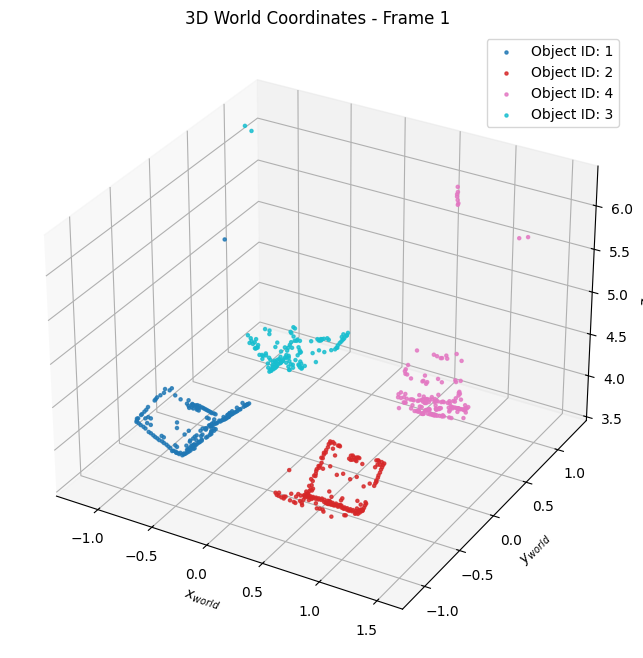

In [8]:

df_pixel_coord = pd.read_csv(f"{PATH}/../results/exp1/pixel_coords_debug.csv", header=None)
df_pixel_coord.columns = ['frame_id', 'object_id', 'tracklet_id', 'u', 'v']
df_3d_coord = pd.read_csv(f"{PATH}/../results/exp1/frontend_map_points_log.csv")

df = pd.merge(
    df_pixel_coord, 
    df_3d_coord, 
    on=['frame_id', 'object_id', 'tracklet_id'], 
    how='inner'
)
print(df.head())

frame_1 = df[df['frame_id'] == 1]

# 2. Setup the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Get unique object IDs to assign colors
object_ids = frame_1['object_id'].unique()
colors = plt.cm.get_cmap('tab10', len(object_ids))

# 4. Plot each object group with a different color
for i, obj_id in enumerate(object_ids):
    obj_data = frame_1[frame_1['object_id'] == obj_id]
    ax.scatter(obj_data['x_world'], 
               obj_data['y_world'], 
               obj_data['z_world'], 
               label=f'Object ID: {int(obj_id)}',
               color=colors(i),
               s=5, alpha=0.8) # Point size

# 5. Labeling and formatting using LaTeX
ax.set_xlabel('$x_{world}$')
ax.set_ylabel('$y_{world}$')
ax.set_zlabel('$z_{world}$')
ax.set_title('3D World Coordinates - Frame 1')
ax.legend()
plt.show()

# Alignment

## obtain corrosponding points

5558
96269
Matched 51 points between the two dataframes.
   frame_id  object_id  tracklet_id    u    v   x_world   y_world   z_world  \
0         1          1          539  488  318 -0.570573 -0.614079  3.908110   
1         1          1          530  482  322 -0.595686 -0.597991  3.927397   
2         1          1          528  396  312 -0.990566 -0.672680  4.149742   
3         1          1          523  482  356 -0.592461 -0.462638  3.923277   
4         1          1          518  398  368 -0.988752 -0.442312  4.177340   

     x_mesh    y_mesh    z_mesh  
0 -0.235115 -0.250407  1.435655  
1 -0.242835 -0.243000  1.427700  
2 -0.402484 -0.274226  1.510334  
3 -0.242885 -0.190719  1.429183  
4 -0.392612 -0.177936  1.487904  


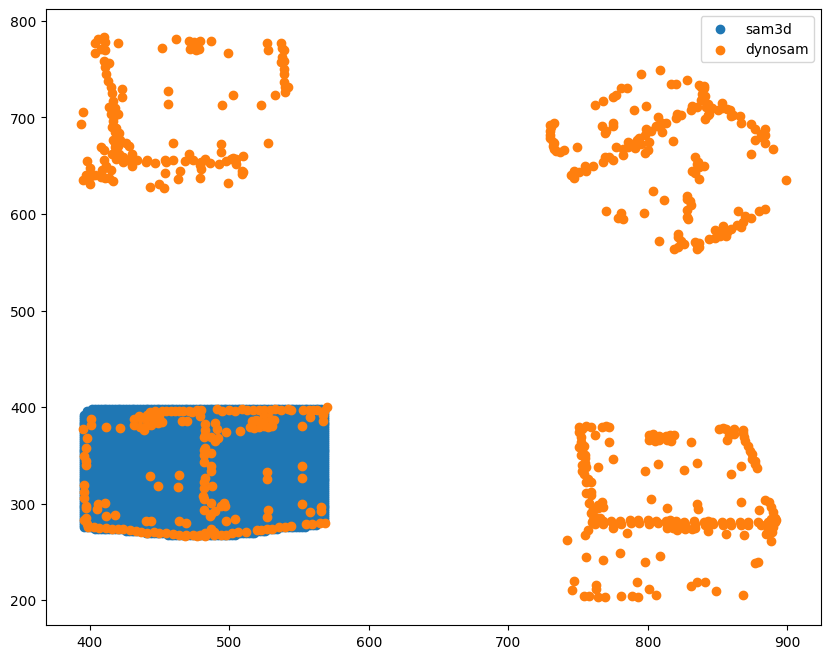

In [9]:
# object 1 combined dataframe
combined_df = pd.merge(
    frame_1, sam3d_df, 
    on=['u', 'v'], 
    how='inner'
)
combined_df = combined_df.reset_index(drop=True)
print(len(sam3d_df))
print(len(df))
print(f"Matched {len(combined_df)} points between the two dataframes.")
print(combined_df.head())

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
ax.scatter(sam3d_df['u'], sam3d_df['v'], label="sam3d")
ax.scatter(frame_1['u'], frame_1['v'], label="dynosam")
ax.legend()
plt.show()

## obtain transformation matrix

Kept 38 inliers out of 48 points.
Alignment RMSE: 0.0361 meters
Excellent alignment! Suitable for precise satellite trajectory prediction.


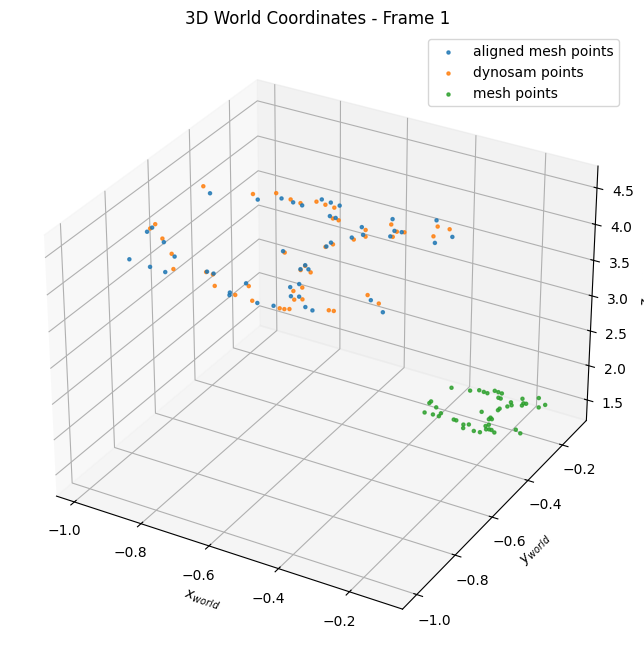

Scale Factor: 2.5346988978565164
Rotation Matrix:
[[ 2.52868838 -0.01257161  0.17399862]
 [ 0.02630355  2.52668223 -0.19970858]
 [-0.17245779  0.20104066  2.52082119]]
Translation Vector: [-0.23799223  0.31609588  0.31829107]


In [23]:
from sklearn.neighbors import LocalOutlierFactor
from skimage.measure import ransac
from skimage.transform import SimilarityTransform

import open3d as o3d

def apply_transformation_matrix(points, model):
    """
    Applies the full 4x4 similarity transformation matrix to a point cloud.
    
    points: [N, 3] numpy array (your SAM3D mesh points)
    model: The fitted skimage.transform.SimilarityTransform object
    """
    # 1. Convert to Homogeneous Coordinates (N, 3) -> (N, 4)
    # We add a column of ones so we can multiply by a 4x4 matrix
    n = points.shape[0]
    ones = np.ones((n, 1))
    points_homo = np.hstack([points, ones])
    
    # 2. Apply the transformation
    # P_new = P_old * M^T (standard row-vector multiplication)
    # model.params is the 4x4 matrix [ [sR, t], [0, 1] ]
    aligned_homo = points_homo @ model.params.T
    
    # 3. Convert back to Cartesian Coordinates (N, 4) -> (N, 3)
    # We simply drop the last column of 1s
    aligned_points = aligned_homo[:, :3]
    
    return aligned_points

def visualize_overlay(aligned_mesh_pts, mesh_pts, world_pts):

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(aligned_mesh_pts[:, 0], 
               aligned_mesh_pts[:, 1], 
               aligned_mesh_pts[:, 2], 
                   label="aligned mesh points",
                   s=5, alpha=0.8) # Point size
    ax.scatter(world_pts[:, 0], 
               world_pts[:, 1], 
               world_pts[:, 2], 
                   label="dynosam points",
                   s=5, alpha=0.8) # Point size
    ax.scatter(mesh_pts[:, 0], 
               mesh_pts[:, 1], 
               mesh_pts[:, 2], 
                   label="mesh points",
                   s=5, alpha=0.8) # Point size
    
    # 5. Labeling and formatting using LaTeX
    ax.set_xlabel('$x_{world}$')
    ax.set_ylabel('$y_{world}$')
    ax.set_zlabel('$z_{world}$')
    ax.set_title('3D World Coordinates - Frame 1')
    ax.legend()
    plt.show()

def estimate_transform(df):
    # 1. Prepare data arrays
    src = df[['x_mesh', 'y_mesh', 'z_mesh']].values
    dst = df[['x_world', 'y_world', 'z_world']].values

    # 2. Preliminary Outlier Removal (Statistical)
    # This removes points that are physically far from the cluster center
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    good_mask = lof.fit_predict(src) == 1
    src_clean = src[good_mask]
    dst_clean = dst[good_mask]


    # 3. RANSAC with SimilarityTransform (Umeyama)
    # This handles Scale, Rotation, and Translation
    model, inliers = ransac(
        (src_clean, dst_clean),
        SimilarityTransform, 
        min_samples=3,
        residual_threshold=0.1, # Max error allowed (in meters)
        max_trials=1000
    )

    print(f"Kept {sum(inliers)} inliers out of {len(src_clean)} points.")
    


    src_centroid = src_clean[inliers].mean(axis=0)
    dst_centroid = dst_clean[inliers].mean(axis=0)

    
    # Apply to your full mesh points
    all_mesh_pts = src_clean
    aligned_mesh_pts = apply_transformation_matrix(all_mesh_pts, model)

    # Apply to your tracking points (optional, if they aren't already world-space)
    world_pts = dst_clean
    
    # Calculate error for the inliers (the points used for alignment)
    diff = aligned_mesh_pts[inliers] - world_pts[inliers]
    rmse = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
    
    print(f"Alignment RMSE: {rmse:.4f} meters")
    if rmse < 0.05:
        print("Excellent alignment! Suitable for precise satellite trajectory prediction.")
    else:
        print("Alignment has some jitter. Check for non-rigid motion or sensor noise.")

    visualize_overlay(aligned_mesh_pts, all_mesh_pts, world_pts)
    
    return model, inliers

# Run it
model, inlier_mask = estimate_transform(combined_df)

# Extract Parameters
s = model.scale
R = model.rotation
t = model.translation

print(f"Scale Factor: {s}")
print(f"Rotation Matrix:\n{R}")
print(f"Translation Vector: {t}")

## perform transformation on mesh

In [26]:
def transform_mesh_data(mesh_dict, model_matrix):
    # 1. Extract vertices [N, 3]
    vertices = np.array(mesh_dict['vertices'])
    
    # 2. Convert to Homogeneous [N, 4]
    ones = np.ones((vertices.shape[0], 1))
    vertices_homo = np.hstack([vertices, ones])
    
    # 3. Apply the 4x4 Matrix
    # V_new = V_old @ M.T
    transformed_vertices_homo = vertices_homo @ model_matrix.T
    
    # 4. Back to [N, 3]
    mesh_dict['vertices'] = transformed_vertices_homo[:, :3]
    
    return mesh_dict

# Usage:
# aligned_mesh = transform_mesh_data(outputs[0]['mesh'], model.params)



<trimesh.Trimesh(vertices.shape=(3393, 3), faces.shape=(6782, 3))>


In [27]:
import trimesh

# 1. Load the GLB
mesh = outputs[0]['glb']

# 2. Apply the 4x4 Matrix
# Trimesh applies this to all vertices and re-calculates normals automatically
mesh.apply_transform(model.params)

# 3. Export the aligned mesh
mesh.export('aligned_object1.glb')

b'glTF\x02\x00\x00\x00\x18\xe0\x01\x00\x08\x03\x00\x00JSON{"scene":0,"scenes":[{"nodes":[0]}],"asset":{"version":"2.0","generator":"https://github.com/mikedh/trimesh"},"accessors":[{"componentType":5125,"type":"SCALAR","bufferView":0,"count":20346,"max":[3392],"min":[0]},{"componentType":5126,"type":"VEC3","byteOffset":0,"bufferView":1,"count":3393,"max":[0.41023191809654236,0.9065314531326294,0.99481600522995],"min":[-0.8799660801887512,-0.2551077604293823,-0.3513644337654114]}],"meshes":[{"name":"geometry_0","extras":{"processed":true},"primitives":[{"attributes":{"POSITION":1},"indices":0,"mode":4}]}],"nodes":[{"name":"world","children":[1]},{"name":"geometry_0","mesh":0}],"buffers":[{"byteLength":122100}],"bufferViews":[{"buffer":0,"byteOffset":0,"byteLength":81384},{"buffer":0,"byteOffset":81384,"byteLength":40716}]} \xf4\xdc\x01\x00BIN\x00L\x08\x00\x00M\x08\x00\x00-\r\x00\x00\xd4\x0c\x00\x00\xcb\x0c\x00\x00\xcd\x0c\x00\x00\xd4\x0c\x00\x00\xce\x0c\x00\x00\xcb\x0c\x00\x00\xa9\x0c\x

In [31]:
os.environ['WEBP_DISABLE_GIF'] = '1'

# Convert trimesh to Open3D
def trimesh_to_open3d(tri_mesh):
    """Converts a trimesh.Trimesh object to an open3d.geometry.TriangleMesh."""
    o3d_mesh = o3d.geometry.TriangleMesh()
    
    # Pass the vertices and faces (Numpy arrays)
    o3d_mesh.vertices = o3d.utility.Vector3dVector(tri_mesh.vertices)
    o3d_mesh.triangles = o3d.utility.Vector3iVector(tri_mesh.faces)
    
    # Important: Recompute normals so the satellite isn't "black" or faceted
    o3d_mesh.compute_vertex_normals()
    
    return o3d_mesh

# 1. Transform your trimesh first
# mesh.apply_transform(model.params)

# 2. Convert using the new function
o3d_mesh = trimesh_to_open3d(mesh)

# 3. Proceed with visualization
# o3d.visualization.draw_geometries([o3d_mesh, pcd_traj])
o3d_mesh.paint_uniform_color([0.7, 0.7, 0.7]) # Grey satellite

# Create your trajectory points from DynoSAM
pcd_traj = o3d.geometry.PointCloud()
pcd_traj.points = o3d.utility.Vector3dVector(frame_1[['x_world', 'y_world', 'z_world']].values)
pcd_traj.paint_uniform_color([1, 0, 0]) # Red trajectory

o3d.visualization.draw_geometries([o3d_mesh, pcd_traj])

In [10]:
# render output for depth
from sam3d_objects.model.backbone.tdfy_dit.utils import render_utils

intrinstics_to_use = [outputs[0]['intrinstics'], outputs[1]['intrinstics'], outputs[2]['intrinstics'], outputs[3]['intrinstics'],]
extrinsics_to_use = [torch.eye(4, device="cuda"), torch.eye(4, device="cuda"), torch.eye(4, device="cuda"), torch.eye(4, device="cuda")]
bg_color = [0.0, 0.0, 0.0]
scene_gs = make_scene(*outputs)
scene_gs = ready_gaussian_for_video_rendering(scene_gs)

render_result = render_utils.render_frames(
        sample=scene_gs,
        extrinsics=extrinsics_to_use,
        intrinsics=intrinstics_to_use,
        options={"bg_color": "random", 'backend': 'gsplat', "ssaa": 1})

Rendering: 0it [00:00, ?it/s]


AssertionError: torch.Size([1, 1])